# TP2 - Vision por Computadora I - CEIA
**Objetivo:** Implementar un detector de máximo enfoque sobre un video aplicando técnicas de análisis espectral similar al que utilizan las cámaras digitales modernas. El video a procesar será: “focus_video.mov”.
1. Se debe implementar un algoritmo que dada una imagen, o región, calcule la métrica propuesta en el paper "Image Sharpness Measure for Blurred Images in Frequency Domain“ y realizar tres experimentos:
    1. Medición sobre todo el frame.
    2. Medición sobre una ROI ubicada en el centro del frame. Area de la ROI = 5 o 10% del area total del frame.
    - Opcional:
        - Medición sobre una matriz de enfoque compuesta por un arreglo de NxM elementos rectangulares equiespaciados. N y M son valores arbitrarios, probar con varios valores 3x3, 7x5, etc ... (al menos 3)
    - Para cada experimento se debe presentar :
        - Una curva o varias curvas que muestren la evolución de la métrica frame a frame donde se vea claramente cuando el algoritmo detecto el punto de máximo enfoque.  

2. Cambiar la métrica de enfoque eligiendo uno de los algoritmos explicados en el apéndice de: Analysis of focus measure operators in shapefrom focus.

El algoritmo de detección a implementar debe detectar y devolver los puntos de máximo enfoque de manera
automática.

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from functools import partial

## Aplicación de algorítmo de Kanjar

Del paper *Image Sharpness Measure for Blurred Images in Frequency Domain* (Kanjar et al.) tenemos que el algorítmo propuesto para determinar el nivel de foco tiene los siguientes pasos:
1. Computar la transformada de Fourier de la imagen: $I\Longrightarrow F$
```python
image_fourier = np.fft.fft2(image)
```
2. Encontrar $F_c$ moviendo el origen de $F$ al centro.
```python
image_fourier = np.fft.fftshift(image_fourier)
```
3. Calcular $AF=abs(F_c)$, es decir el valor absoluto elemento a elemento de $F_c$.
```python
af = np.abs(image_fourier)
```
4. Calcular el máximo valor $M$ del componente de frecuencia de $AF$.
```python
max_af = np.max(af)
```
5. Contar la cantidad de pixeles $T_H$ que tienen valor $>thres=\frac{M}{1000}$.
```python
thres = max_af / 1000
th = 0
for row in af:
    for pixel in row:
        if pixel > thres:
            th += 1
```
6. Calcular la métrica como $$\text{Image Quality Measure}=\frac{T_H}{m\cdot n}$$ siendo $m$ y $n$ el tamaño de la imagen en pixeles.
```python
m, n = image.shape
iqm = th / (m * n)
```

A continuación se tiene el algoritmo implementado en una función:

In [2]:
def kanjar_algorithm(image):
    m, n = image.shape
    # Genero la transformacion de Fourier de la imagen
    image_fourier = np.fft.fft2(image)
    # Shifteo el origen de la TF al centro
    image_fourier = np.fft.fftshift(image_fourier)
    # Computo el valor absoluto de la TF centrada
    af = np.abs(image_fourier)
    # Calculo el maximo de AF
    max_af = np.max(af)
    # Calculo la cantidad de pixeles con valor > thres
    thres = max_af / 1000
    th = 0
    for row in af:
        for pixel in row:
            if pixel > thres:
                th += 1
    # Computo la metrica
    iqm = th / (m * n)
    return iqm

Defino una función que permita computar la métrica (u otra métrica que tenga por input sólo el frame y como output el valor de la métrica) a partir de un video, y además que me permita computar la métrica para el centro del frame (definiendo un cierto porcentaje para tomar del centro) o para una matriz de enfoque (dando el tamaño de cada zona y la cantidad de zonas totales en cada dirección, siempre centradas en la imagen). Esta función nos devuelve una lista con el valor de la métrica en cada frame del video.

In [3]:
def compute_focus_metric_for_video(
        video_path,
        focus_metric_fun=kanjar_algorithm,
        center_frame = False,
        focus_matrix = False,
        center_percentage = None,
        focus_matrix_zone_size = (None, None),
        focus_matrix_zones = (None, None),
        ):

    # Check de que tenga los datos necesarios según la zona de calculo
    if center_frame and focus_matrix:
        return ValueError("center_frame y focus_matrix no pueden ambos ser True, sólo 1 puede serlo.")
    if center_frame:
        if not bool(center_percentage):
            return ValueError("falta especificar center_percentage para el cómputo de la métrica en el centro del frame.")
    if focus_matrix:
        if (
            not bool(focus_matrix_zone_size[0]) or not bool(focus_matrix_zone_size[1]) or
            not bool(focus_matrix_zones[0]) or not bool(focus_matrix_zones[1])
        ):
            return ValueError("falta especificar alguna de las tuplas para cómputo por matriz de enfoque. A saber: focus_matrix_zone_size (tamaño de las zonas de enfoque en cada dirección) y focus_matrix_zones (cantidad de zonas de enfoque en cada dirección)")
    
    captura_video = cv.VideoCapture(video_path)

    metric = []
    if not captura_video.isOpened():
        raise Exception("Error al abrir el archivo de video")
    else:
        i = 0
        while True:
            ret, frame = captura_video.read()
            if not ret:
                break
            frame = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)

            # Modificacion del frame segun la zona/zonas de enfoque definidas
            m,n = frame.shape
            if center_frame:
                ymin, ymax = int(m/2 - center_percentage/2 * m), int(m/2 + center_percentage/2 * m)
                xmin, xmax = int(n/2 - center_percentage/2 * n), int(n/2 + center_percentage/2 * n)
                frame = frame[ymin:ymax, xmin:xmax]
            elif focus_matrix:
                center_x, center_y = int(m/2), int(n/2)
                rows = [
                    (int((center_x + 2*(i - focus_matrix_zones[0])*focus_matrix_zone_size[0]) - (focus_matrix_zone_size[0] - 1)/2), 
                    int((center_x + 2*(i - focus_matrix_zones[0])*focus_matrix_zone_size[0]) + (focus_matrix_zone_size[0] - 1)/2))
                    for i in range(focus_matrix_zones[0]*2 + 1)
                ]
                cols = [
                    (int((center_y + 2*(i - focus_matrix_zones[1])*focus_matrix_zone_size[1]) - (focus_matrix_zone_size[1] - 1)/2), 
                    int((center_y + 2*(i - focus_matrix_zones[1])*focus_matrix_zone_size[1]) + (focus_matrix_zone_size[1] - 1)/2))
                    for i in range(focus_matrix_zones[1]*2 + 1)
                ]
                frame = np.concatenate([frame[r1:r2, c1:c2] for r1,r2 in rows for c1,c2 in cols])
            # Si full_frame, no se modifica frame

            metric.append(focus_metric_fun(frame))

    most_focused = np.argmax(metric)
    print(f"El frame con mayor enfoque es el {most_focused}.")
    return metric

Defino la función `get_focus_frames` que nos entrega una lista de tuplas que nos dicen según un threshold del valor de la métrica si el frame está o no enfocado, dando el mínimo y máximo de periodos de enfoque. Además, por defecto el threshold es respecto del máximo de `metric_list`, de esta forma el threshold es normalizado respecto de la serie.

In [4]:
def get_focus_frames(metric_list, thres, norm=True):
    focus_zones = []
    focused = False
    thres = thres if not norm else thres * np.max(metric_list)
    for frame, point in enumerate(metric_list):
        if point > thres and not focused:
            focused = True
            focus_zones.append(frame)
        if focused and point < thres:
            focused = False
            focus_zones[-1] = (focus_zones[-1],frame)

    return focus_zones

Aplicamos entonces las funciones para comparar la medición sobre todo el frame, el centro del mismo y sobre una matríz de enfoque. Establecemos como umbral para definir que está enfocada la imagen como un 80% del máximo de la métrica en todo el video.

In [5]:
print("Alg. Kanjar (full frame):")
kanjar_full_frame = compute_focus_metric_for_video(
                        video_path='focus_video.mov'
                    )

print("Alg. Kanjar (center frame):")
kanjar_center_frame = compute_focus_metric_for_video(
                        video_path='focus_video.mov',
                        center_frame=True,
                        center_percentage=0.05
                    )

print("Alg. Kanjar (matriz de enfoque, size:3x3, zones:3x3):")
kanjar_focus_matrix_33_33 = compute_focus_metric_for_video(
                        video_path='focus_video.mov',
                        focus_matrix=True,
                        focus_matrix_zone_size=(3,3),
                        focus_matrix_zones=(3,3)
                    )

print("Alg. Kanjar (matriz de enfoque, size:3x3, zones:7x5):")
kanjar_focus_matrix_33_75 = compute_focus_metric_for_video(
                        video_path='focus_video.mov',
                        focus_matrix=True,
                        focus_matrix_zone_size=(3,3),
                        focus_matrix_zones=(7,5)
                    )

print("Alg. Kanjar (matriz de enfoque, size:5x5, zones:3x3):")
kanjar_focus_matrix_55_33 = compute_focus_metric_for_video(
                        video_path='focus_video.mov',
                        focus_matrix=True,
                        focus_matrix_zone_size=(5,5),
                        focus_matrix_zones=(3,3)
                    )

print("Alg. Kanjar (matriz de enfoque, size:5x5, zones:7x5):")
kanjar_focus_matrix_55_75 = compute_focus_metric_for_video(
                        video_path='focus_video.mov',
                        focus_matrix=True,
                        focus_matrix_zone_size=(5,5),
                        focus_matrix_zones=(7,5)
                    )

cases = {
    'kanjar full frame': kanjar_full_frame,
    'kanjar center frame': kanjar_center_frame,
    'kanjar focus matrix size:3x3 zones:3x3': kanjar_focus_matrix_33_33,
    'kanjar focus matrix size:3x3 zones:7x5': kanjar_focus_matrix_33_75,
    'kanjar focus matrix size:5x5 zones:3x3': kanjar_focus_matrix_55_33,
    'kanjar focus matrix size:5x5 zones:7x5': kanjar_focus_matrix_55_75,
}
focus_zones = {}
for case_name in cases.keys():
    focus_zones[case_name] = get_focus_frames(cases[case_name], thres=0.8)
total_frames = len(kanjar_full_frame)

Alg. Kanjar (full frame):
El frame con mayor enfoque es el 109.
Alg. Kanjar (center frame):
El frame con mayor enfoque es el 95.
Alg. Kanjar (matriz de enfoque, size:3x3, zones:3x3):
El frame con mayor enfoque es el 82.
Alg. Kanjar (matriz de enfoque, size:3x3, zones:7x5):
El frame con mayor enfoque es el 109.
Alg. Kanjar (matriz de enfoque, size:5x5, zones:3x3):
El frame con mayor enfoque es el 111.
Alg. Kanjar (matriz de enfoque, size:5x5, zones:7x5):
El frame con mayor enfoque es el 107.


In [6]:
def plot_compare_metrics(cases, cases_to_plot, dist_to_bottom=0.2):
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    fig, axs = plt.subplots(1,2, figsize=(10,5), sharex=True)
    for i, case_name in enumerate(cases_to_plot):
        case = cases[case_name]

        axs[0].scatter(range(total_frames), case, s=10, label=case_name)
        axs[1].scatter(range(total_frames), case/np.max(case), s=10, label=case_name)

    axs[1].hlines(y=0.8, xmin=0, xmax=total_frames, color='black', linestyle='dashed')
    axs[1].set_ylim(0,1.05)
    [ax.set_xlim(0,total_frames) for ax in axs]
    [ax.set_xlabel('Frame') for ax in axs]
    axs[0].set_ylabel('Métrica')
    axs[1].set_ylabel('Métrica normalizada al máximo')
    handles, labels = axs[0].get_legend_handles_labels()
    fig.legend(
        handles = handles,
        labels = labels,
        loc = 'lower center',
        ncol = 2,
        bbox_to_anchor = (0.5, -0.05)
    )
    fig.suptitle("Métrica de enfoque en función de los frames")
    plt.tight_layout()
    plt.subplots_adjust(bottom=dist_to_bottom)
    plt.show()

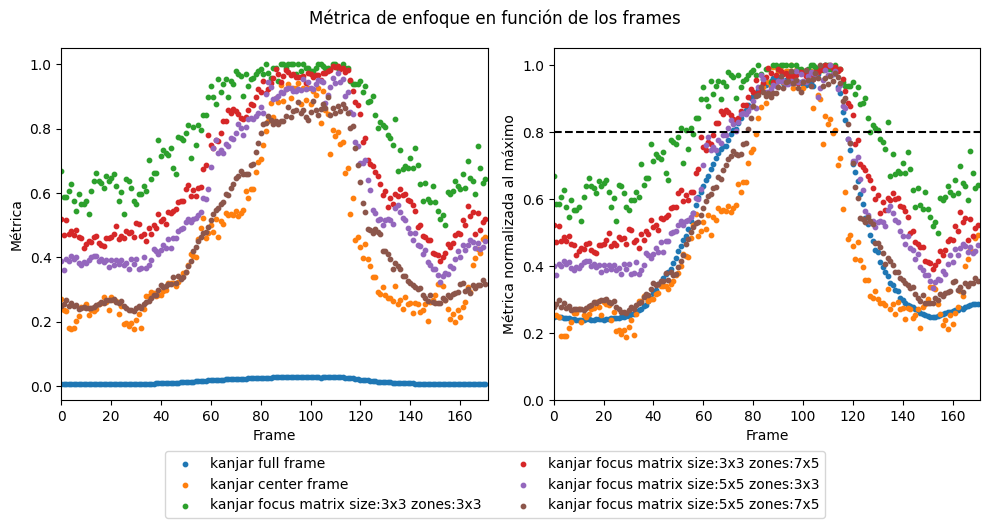

In [7]:
cases_to_plot = [
    'kanjar full frame',
    'kanjar center frame',
    'kanjar focus matrix size:3x3 zones:3x3',
    'kanjar focus matrix size:3x3 zones:7x5',
    'kanjar focus matrix size:5x5 zones:3x3',
    'kanjar focus matrix size:5x5 zones:7x5',
]
plot_compare_metrics(cases, cases_to_plot)

Grafiquemos ahora los rangos de frame predichos por cada caso.

In [8]:
def plot_focus_ranges(focus_zones, cases_to_plot):
    fig, ax = plt.subplots(1,1)
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    for i, case_name in enumerate(cases_to_plot):
        focus_zones_case = focus_zones[case_name]
        color = colors[i % len(colors)]
        for focus_zone in focus_zones_case:
            ax.hlines(y=i, xmin=focus_zone[0], xmax=focus_zone[1], linewidth=2, color=color)
            ax.plot(focus_zone, [i,i], "|", color=color)
    ax.set_xlim(0,total_frames)
    ax.set_yticks(range(len(cases_to_plot)))
    ax.set_yticklabels(cases_to_plot)
    ax.set_title("Rango de frames considerados enfocados")
    plt.show()

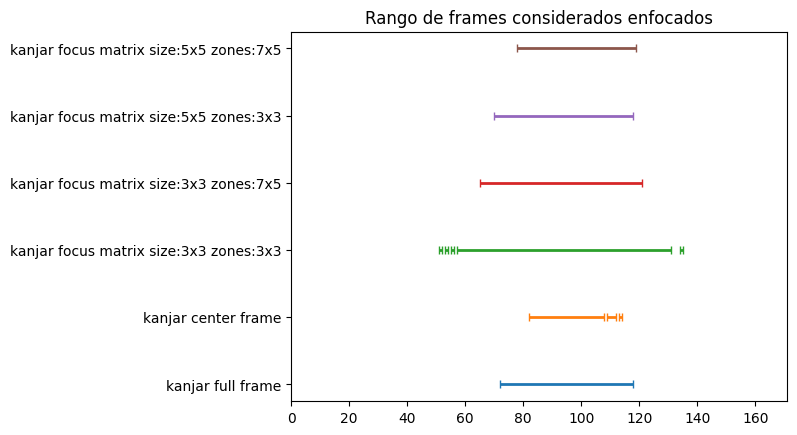

In [9]:
plot_focus_ranges(focus_zones, cases_to_plot)

Observamos que todos los modelos comparten una zona de enfoque central, aunque algunos se expanden en los frames que consideran enfocados (como el caso de la matriz de 3x3;3x3) y otros consideran un rango más acotado (como el caso del centro del frame).

Algo a notar es que en 2 casos se tienen unos frames en los que se oscila entre enfocado y no enfocado, si observamos el gráfico de la métrica en función de los frames, vemos que es una zona de oscilación del valor de la métrica.

Defino otra función que permite visualizar el video, y además poner debajo del mismo el texto si según una métrica está enfocado 

In [10]:
def view_video(captura_video, focus_zones):
    '''
    '''
    # Va al frame 0
    captura_video.set(cv.CAP_PROP_POS_FRAMES, 0)
    if not captura_video.isOpened():
        print("Error al abrir el archivo de video")
    else:
        # Obtén la tasa de cuadros (frame rate) del video
        fps = int(captura_video.get(cv.CAP_PROP_FPS)) * 0.25
        #fps = 35
        delay = int(600 / fps)
        
        banner_height = 40 + 30 * (len(focus_zones.keys()) - 1) # How tall you want the banner to be

        frame_count = 0
        while True:
            ret, frame = captura_video.read()
            frame_count += 1
            if not ret:
                break

            h, w, channels = frame.shape
            composite_frame = np.zeros((h+banner_height, w, channels), dtype=np.uint8)
            composite_frame[0:h, 0:w] = frame

            percent = 0.05
            percent = 0.10
            cv.rectangle(composite_frame, (int(w/2 - w*percent/2), int(h/2 - h*percent/2)), (int(w/2 + w*percent/2), int(h/2 + h*percent/2)), (0, 255, 0), 3)
            
            metric_counter = 0
            for metric in focus_zones.keys():
                in_focus = False
                for focus_zone in focus_zones[metric]:
                    if frame_count >= focus_zone[0] and frame_count <= focus_zone[1]:
                        in_focus = True
                banner_text = f"{metric}: Enfocado" if in_focus else f"{metric}: No enfocado"

                text_position = (20, h + 30 * (1 + metric_counter)) # X, Y coordinates for the text start
                metric_counter += 1
                cv.putText(composite_frame, banner_text, text_position, cv.FONT_HERSHEY_SIMPLEX, 
                            0.8, (255, 255, 255), 2, cv.LINE_AA)
            
            # Mostrar el frame combinado
            cv.imshow('Video Original y Blur Gaussiano', composite_frame)
            
            # Salir del loop si se presiona la tecla 'q'
            if cv.waitKey(delay) & 0xFF == ord('q'):
                break

    # Cierra todas las ventanas
    cv.destroyAllWindows()

Podemos ver superpuesto con el video cuando cada aplicación del algorítmo de Kanjar predice enfoque.

In [11]:
video_path = 'focus_video.mov'
captura_video = cv.VideoCapture(video_path)
view_video(
    captura_video=captura_video,
    focus_zones=focus_zones
)

QFontDatabase: Cannot find font directory /home/jiteich/repos/ceia/vision_computadora_i/TPs/tp2/.venv/lib/python3.11/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/jiteich/repos/ceia/vision_computadora_i/TPs/tp2/.venv/lib/python3.11/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/jiteich/repos/ceia/vision_computadora_i/TPs/tp2/.venv/lib/python3.11/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/jiteich/repos/ceia/vision_computadora_i/TPs/tp2/.venv/lib/python3.11/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some 

## Métrica adicional

Como métrica adicional decidí utilizar la denominada *LAP2* o *Modified Laplacian* propuesta por *Nayar*, ya que fue el algorítmo que mejor performance tuvo en las imagenes de los 3 origenes planteados en el paper. La misma se computa de la siguiente forma, considerando que se aplica a las posiciones $(i,j)$ para la posición $(x,y)$:
$$
\phi_{x,y} = \sum_{(i,j)\in\Omega(x,y)} \Delta_m I(i,j)
$$
siendo
$$
\Delta_m I(i,j) = \left| I \ast L_x\right| +  \left| I \ast L_y\right|
$$
y 
$$
L_x = \left[-1; 2; -1\right] \quad L_y=L_x^T
$$
Para el caso de este TP, queremos una métrica para todo el frame, una zona central o la combinación de varias zonas (matriz de enfoque). Entonces hacemos que $(i,j)$ contenga a toda la zona de interés, y obtenemos un único $\phi$.

Adicionalmente, para compararlo, debemos nuevamente normalizar, ya que los valores de esta métrica no están en el mismo orden de magnitud que las métricas previamente utilizadas.

A continuación se tiene la función que computa la métrica dado un frame:

In [12]:
from scipy.signal import convolve2d
def modified_laplacian_algorithm(frame):
    # Mascaras de convolución
    L_x = np.array([[-1, 2, -1]])
    L_y = L_x.T

    # Aplico la convolució\left| I \ast L_x\right|n
    ILx = convolve2d(frame, L_x, mode='same', boundary='symm')
    ILy = convolve2d(frame, L_y, mode='same', boundary='symm')

    # Computo la métrica
    delta_m_I = np.abs(ILx) + np.abs(ILy)
    metric = np.sum(delta_m_I)

    return metric

In [13]:
print("Alg. Lap. Mod. (full frame):")
lap2_full_frame = compute_focus_metric_for_video(
                        video_path='focus_video.mov',
                        focus_metric_fun=modified_laplacian_algorithm,
                    )

print("Alg. Lap. Mod. (center frame):")
lap2_center_frame = compute_focus_metric_for_video(
                        video_path='focus_video.mov',
                        focus_metric_fun=modified_laplacian_algorithm,
                        center_frame=True,
                        center_percentage=0.05
                    )

print("Alg. Lap. Mod. (matriz de enfoque, size:3x3, zones:3x3):")
lap2_focus_matrix_33_33 = compute_focus_metric_for_video(
                        video_path='focus_video.mov',
                        focus_metric_fun=modified_laplacian_algorithm,
                        focus_matrix=True,
                        focus_matrix_zone_size=(3,3),
                        focus_matrix_zones=(3,3)
                    )

print("Alg. Lap. Mod. (matriz de enfoque, size:3x3, zones:7x5):")
lap2_focus_matrix_33_75 = compute_focus_metric_for_video(
                        video_path='focus_video.mov',
                        focus_metric_fun=modified_laplacian_algorithm,
                        focus_matrix=True,
                        focus_matrix_zone_size=(3,3),
                        focus_matrix_zones=(7,5)
                    )

print("Alg. Lap. Mod. (matriz de enfoque, size:5x5, zones:3x3):")
lap2_focus_matrix_55_33 = compute_focus_metric_for_video(
                        video_path='focus_video.mov',
                        focus_metric_fun=modified_laplacian_algorithm,
                        focus_matrix=True,
                        focus_matrix_zone_size=(5,5),
                        focus_matrix_zones=(3,3)
                    )

print("Alg. Lap. Mod. (matriz de enfoque, size:5x5, zones:7x5):")
lap2_focus_matrix_55_75 = compute_focus_metric_for_video(
                        video_path='focus_video.mov',
                        focus_metric_fun=modified_laplacian_algorithm,
                        focus_matrix=True,
                        focus_matrix_zone_size=(5,5),
                        focus_matrix_zones=(7,5)
                    )

cases['lap2 full frame'] = lap2_full_frame
cases['lap2 center frame'] = lap2_center_frame
cases['lap2 focus matrix size:3x3 zones:3x3'] = lap2_focus_matrix_33_33
cases['lap2 focus matrix size:3x3 zones:7x5'] = lap2_focus_matrix_33_75
cases['lap2 focus matrix size:5x5 zones:3x3'] = lap2_focus_matrix_55_33
cases['lap2 focus matrix size:5x5 zones:7x5'] = lap2_focus_matrix_55_75

focus_zones['lap2 full frame'] = get_focus_frames(lap2_full_frame, thres=0.8)
focus_zones['lap2 center frame'] = get_focus_frames(lap2_center_frame, thres=0.8)
focus_zones['lap2 focus matrix size:3x3 zones:3x3'] = get_focus_frames(lap2_focus_matrix_33_33, thres=0.8)
focus_zones['lap2 focus matrix size:3x3 zones:7x5'] = get_focus_frames(lap2_focus_matrix_33_75, thres=0.8)
focus_zones['lap2 focus matrix size:5x5 zones:3x3'] = get_focus_frames(lap2_focus_matrix_55_33, thres=0.8)
focus_zones['lap2 focus matrix size:5x5 zones:7x5'] = get_focus_frames(lap2_focus_matrix_55_75, thres=0.8)

Alg. Lap. Mod. (full frame):
El frame con mayor enfoque es el 111.
Alg. Lap. Mod. (center frame):
El frame con mayor enfoque es el 95.
Alg. Lap. Mod. (matriz de enfoque, size:3x3, zones:3x3):
El frame con mayor enfoque es el 91.
Alg. Lap. Mod. (matriz de enfoque, size:3x3, zones:7x5):
El frame con mayor enfoque es el 109.
Alg. Lap. Mod. (matriz de enfoque, size:5x5, zones:3x3):
El frame con mayor enfoque es el 103.
Alg. Lap. Mod. (matriz de enfoque, size:5x5, zones:7x5):
El frame con mayor enfoque es el 105.


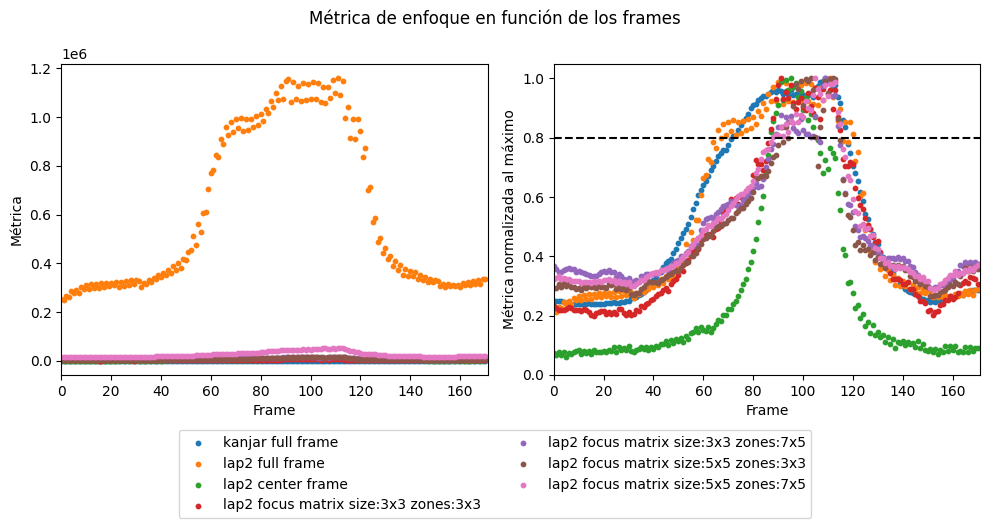

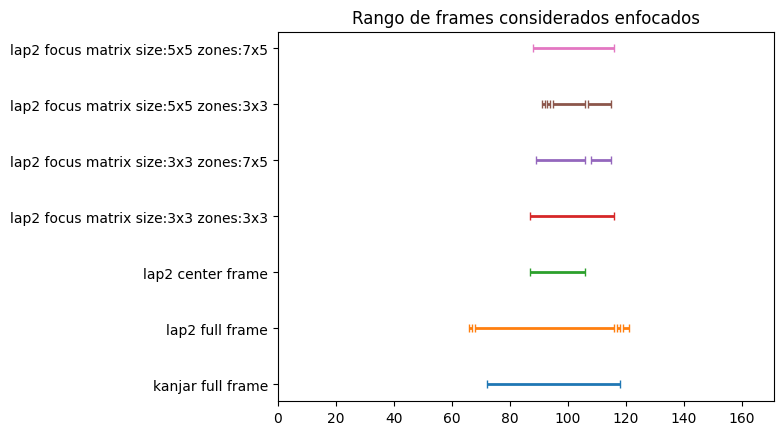

In [14]:
cases_to_plot = [
    'kanjar full frame',
    'lap2 full frame',
    'lap2 center frame',
    'lap2 focus matrix size:3x3 zones:3x3',
    'lap2 focus matrix size:3x3 zones:7x5',
    'lap2 focus matrix size:5x5 zones:3x3',
    'lap2 focus matrix size:5x5 zones:7x5',
]
plot_compare_metrics(cases, cases_to_plot, dist_to_bottom=0.25)
plot_focus_ranges(focus_zones, cases_to_plot)

Podemos apreciar que, salvo para el caso de utilizar todo el frame, este algorítmo predice un tramo más acotado como enfocado. Especialmente el caso del centro del frame se tienen pocos frames considerados enfocados.

## Aplicación de unsharp masking

Defino la función para aplicar unsharp mask antes de la función de cálculo de métrica

In [15]:
def unsharp_mask(frame, metric_function=kanjar_algorithm):
    frame_gaussian = cv.GaussianBlur(frame, (0,0), 2.0)
    frame_high_freq = frame - frame_gaussian
    frame_sharp = frame + frame_high_freq
    return metric_function(frame_sharp)

unsharp_mask_kanjar = partial(unsharp_mask, metric_function=kanjar_algorithm)
unsharp_mask_mod_lap = partial(unsharp_mask, metric_function=modified_laplacian_algorithm)

Comparamos aplicar unsharp mask para los casos *full frame* tanto la el algorítmo de Kanjar como para el algorítmo del laplaciano modificado.

In [16]:
um_kanjar_full_frame = compute_focus_metric_for_video(
                        video_path='focus_video.mov',
                        focus_metric_fun=unsharp_mask_kanjar
                    )
um_lap2_full_frame = compute_focus_metric_for_video(
                        video_path='focus_video.mov',
                        focus_metric_fun=unsharp_mask_mod_lap,
                    )

cases['unsharp mask kanjar'] = um_kanjar_full_frame
cases['unsharp mask lap2'] = um_lap2_full_frame

focus_zones['unsharp mask kanjar'] = get_focus_frames(um_kanjar_full_frame, thres=0.8)
focus_zones['unsharp mask lap2'] = get_focus_frames(um_lap2_full_frame, thres=0.8)

El frame con mayor enfoque es el 93.
El frame con mayor enfoque es el 111.


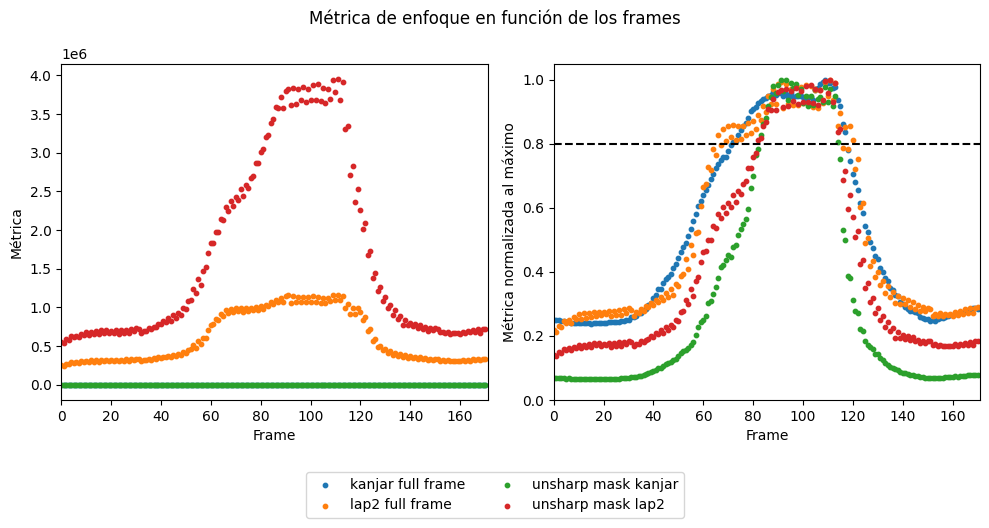

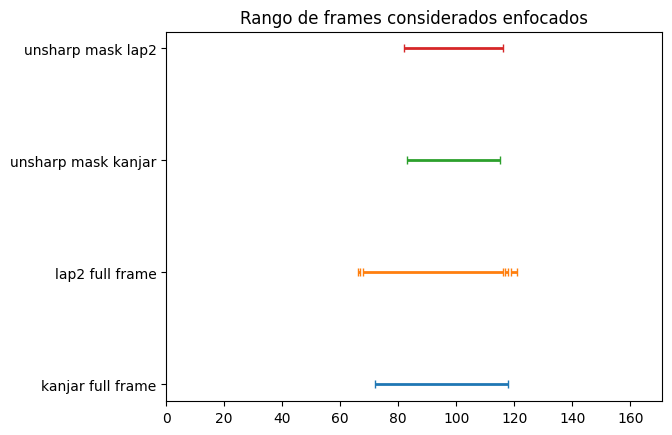

In [17]:
cases_to_plot = [
    'kanjar full frame',
    'lap2 full frame',
    'unsharp mask kanjar',
    'unsharp mask lap2'
]
plot_compare_metrics(cases, cases_to_plot)
plot_focus_ranges(focus_zones, cases_to_plot)

Si comparamos ahora utilizando unsharp mask, vemos que aplicar este procesamiento previo genera una reducción de los frames considerados enfocados, así como también mayor "definición" en la curva de métrica en función de los frames de cuando se está enfocado.